In [1]:
import pandas as pd

# The Data

In [2]:
df_boston = pd.read_csv('Boston House Prices.csv')

In [3]:
df_boston.describe()

,Rooms,Distance,Value
count,506.000000,506.000000,506.000000
mean,6.284634,3.795043,22.532806
std,0.702617,2.105710,9.197104
min,3.561000,1.129600,5.000000
25%,5.885500,2.100175,17.025000
50%,6.208500,3.207450,21.200000
75%,6.623500,5.188425,25.000000
max,8.780000,12.126500,50.000000


# Linear Regression with Statsmodels

In [4]:
import statsmodels.api as sm

## Simple Liner Regression

### Define the dependent and independent variable

In [5]:
y = df_boston['Value'] # dependent variable
x = df_boston['Rooms'] # independent variable

### Exploring the dataset

<Axes: xlabel='Rooms', ylabel='Value'>

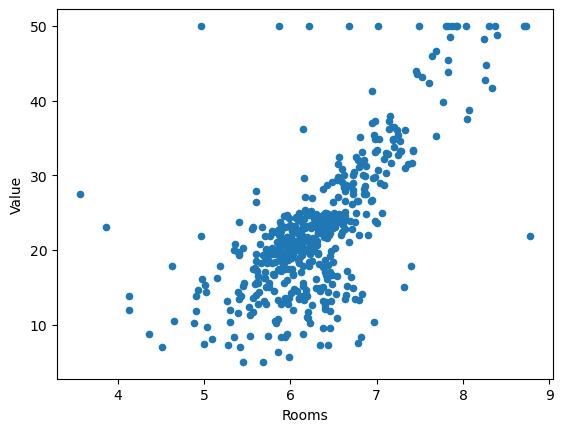

In [6]:
df_boston.plot(kind='scatter',
              x = 'Rooms',
              y = 'Value')

### Making the regression: Adding a constant and fitting the model

Statmodels doesn't add a constant by default, so we have to do it on our own

In [7]:
x = sm.add_constant(x) # adding a constant
lm = sm.OLS(y, x).fit() # fitting the model [lm = linear model]

In [8]:
# predict
lm.predict(x)

0      25.175746
1      23.774021
2      30.728032
3      29.025938
4      30.382152
         ...    
501    25.339584
502    21.034286
503    28.825691
504    27.169108
505    20.215096
Length: 506, dtype: float64

### The Regression Table

In [9]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Value   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           2.49e-74
Time:                        19:54:42   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.6706      2.650    -13.084      0.000     -39.877     -29.465
Rooms          9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Linear Regression Equation

In [10]:
# Rooms coef: 9.1021
# Constant coef: -34.6706

# Linear equation: y = ax + b
y_pred = 9.1021*x['Rooms'] - 34.6706

### Plotting The Regression Line

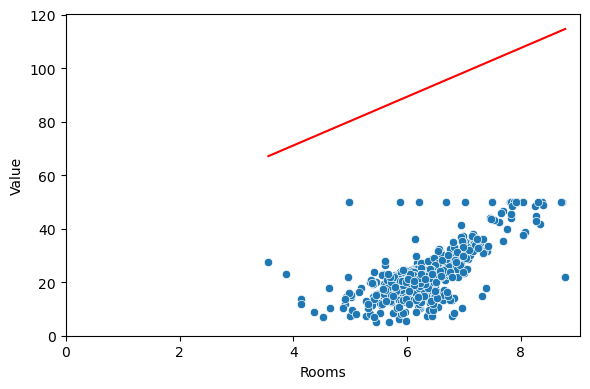

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
# plotting the data points
plt.figure(figsize=(6,4), tight_layout = True)
sns.scatterplot(x=x['Rooms'], y=y)

# plotting the line
sns.lineplot(x=x['Rooms'], y=y_pred, color='red')

#axes
plt.xlim(0)
plt.ylim(0)
# Save and show
plt.savefig('linear_regression')
plt.show()